In [1]:
import os
os.getcwd()
import sys 
sys.path.append('/data/users/miroojin/saksham/watermark-adapters')
os.environ["CUDA_VISIBLE_DEVICES"] = "4, 5"
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from src.mbmark import MbMark
import json

In [2]:
model_name = "meta-llama/Llama-2-7b-hf"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

lm_head = model.lm_head.weight.data.cpu()

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    device_map="auto")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Save the lm_head tensor to a file
# torch.save(lm_head, "../saved_models/llama2_7b_lm_head.pt")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
# Load sentence transformer embedding model
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer('all-MiniLM-L6-v2', device='cuda')

In [14]:
selector_matrix_path = "../saved_models/openwebtext_Llama-2-7b-hf/selector_matrix_k235.pth"
selector_matrix = torch.load(selector_matrix_path)

config_path = "../output/mb/Llama-2-7b-hf/output_delta=1.0_gamma=0.25_k=235_seed=15485863_watermark=mb_dataset=realnewslike.json"

config_path_old_qwen = "../output/output_delta=1.0_gamma=0.25_k=235_seed=15485863_watermark=mb_dataset=realnewslike.json"

with open(config_path, 'r') as f:
    output = json.load(f)

with open(config_path_old_qwen, 'r') as f:
    output_old_qwen = json.load(f)

config = output["config"]
k = selector_matrix.shape[0]
gamma = config["gamma"]
delta = config["delta"]
seed = config["hash_key"]


In [5]:

watermark = MbMark.mb(
        delta=delta,
        gamma=gamma,
        seed=seed,
        final_weight=selector_matrix,
        model=model,
        tokenizer=tokenizer,
        unembedding_param_name=config["unembedding_param_name"],
    )

In [19]:
model_text = output["samples"]["model_text"]
dipper_text_l60 = output["samples"]["dipper_text_lex60_order0"]
dipper_text_l20 = output["samples"]["dipper_text_lex20_order0"]
qwen25_14b_instruct_paraphrase = output["samples"]["qwen_qwen2_5_14b_instruct_paraphrase"]
qwen25_14b_instruct_paraphrase_old = output_old_qwen["samples"]["qwen25_14b_instruct_paraphrase"]
gpt_4_1_paraphrase = output["samples"]["gpt_4_1_paraphrase"]


In [20]:
# Embedding cosine similarities (sentence-transformer)
emb_model = embedder.encode(model_text, convert_to_tensor=True, normalize_embeddings=True)
emb_l60 = embedder.encode(dipper_text_l60, convert_to_tensor=True, normalize_embeddings=True)
emb_l20 = embedder.encode(dipper_text_l20, convert_to_tensor=True, normalize_embeddings=True)
emb_qwen = embedder.encode(qwen25_14b_instruct_paraphrase, convert_to_tensor=True, normalize_embeddings=True)
emb_gpt = embedder.encode(gpt_4_1_paraphrase, convert_to_tensor=True, normalize_embeddings=True)
emb_qwen_old = embedder.encode(qwen25_14b_instruct_paraphrase_old, convert_to_tensor=True, normalize_embeddings=True)

emb_cos_l60 = (emb_model * emb_l60).sum(dim=-1)
emb_cos_l20 = (emb_model * emb_l20).sum(dim=-1)
emb_cos_qwen = (emb_model * emb_qwen).sum(dim=-1)
emb_cos_qwen_old = (emb_model * emb_qwen_old).sum(dim=-1)
emb_cos_gpt = (emb_model * emb_gpt).sum(dim=-1)

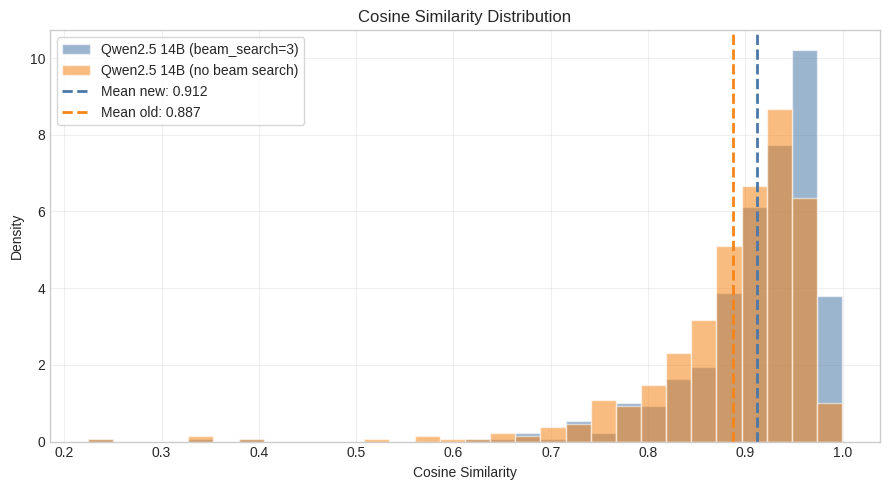

In [25]:
# Compare cosine similarity distributions: new Qwen vs old Qwen
import matplotlib.pyplot as plt
qwen_new = emb_cos_qwen.detach().cpu().numpy()
qwen_old = emb_cos_qwen_old.detach().cpu().numpy()

plt.style.use("seaborn-v0_8-whitegrid")
colors = {"new": "#4c78a8", "old": "#f58518"}

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(qwen_new, bins=30, alpha=0.55, density=True, color=colors["new"], label="Qwen2.5 14B (beam_search=3)", edgecolor="white")
ax.hist(qwen_old, bins=30, alpha=0.55, density=True, color=colors["old"], label="Qwen2.5 14B (no beam search)", edgecolor="white")

mean_new = qwen_new.mean()
mean_old = qwen_old.mean()
ax.axvline(mean_new, color=colors["new"], linestyle="--", linewidth=2, label=f"Mean new: {mean_new:.3f}")
ax.axvline(mean_old, color=colors["old"], linestyle="--", linewidth=2, label=f"Mean old: {mean_old:.3f}")

ax.set_title("Cosine Similarity Distribution")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Density")
ax.grid(alpha=0.3)
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

In [8]:
# Indices with lowest/highest cosine similarity
def min_max_indices(scores, name):
    if hasattr(scores, "cpu"):
        scores_np = scores.detach().cpu().numpy()
    else:
        scores_np = scores
    min_idx = int(scores_np.argmin())
    max_idx = int(scores_np.argmax())
    return {
        "name": name,
        "min_idx": min_idx,
        "min_score": float(scores_np[min_idx]),
        "max_idx": max_idx,
        "max_score": float(scores_np[max_idx]),
    }

min_max_summary = [
    min_max_indices(emb_cos_l60, "emb_cos_l60"),
    min_max_indices(emb_cos_l20, "emb_cos_l20"),
    min_max_indices(emb_cos_qwen, "emb_cos_qwen"),
    min_max_indices(emb_cos_gpt, "emb_cos_gpt"),
]
min_max_summary

[{'name': 'emb_cos_l60',
  'min_idx': 170,
  'min_score': 0.3599169850349426,
  'max_idx': 373,
  'max_score': 0.9692776799201965},
 {'name': 'emb_cos_l20',
  'min_idx': 84,
  'min_score': 0.4147762060165405,
  'max_idx': 391,
  'max_score': 0.9915556311607361},
 {'name': 'emb_cos_qwen',
  'min_idx': 395,
  'min_score': 0.2240542620420456,
  'max_idx': 220,
  'max_score': 0.9997050762176514},
 {'name': 'emb_cos_gpt',
  'min_idx': 499,
  'min_score': 0.6078535318374634,
  'max_idx': 323,
  'max_score': 0.9892487525939941}]

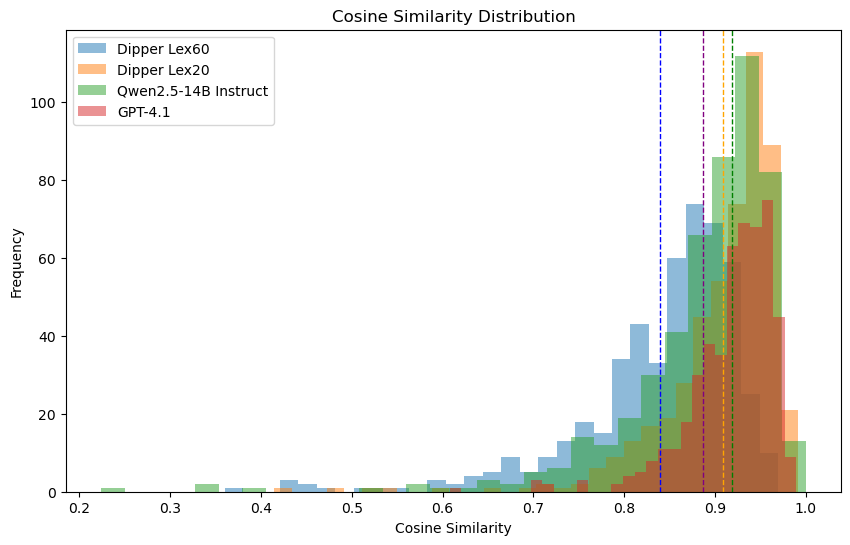

In [9]:

# Plot the cosine similarities histogram
plt.figure(figsize=(10, 6))
plt.hist(emb_cos_l60.cpu().numpy(), bins=30, alpha=0.5, label='Dipper Lex60')
plt.hist(emb_cos_l20.cpu().numpy(), bins=30, alpha=0.5, label='Dipper Lex20')
plt.hist(emb_cos_qwen.cpu().numpy(), bins=30, alpha=0.5, label='Qwen2.5-14B Instruct')
plt.hist(emb_cos_gpt.cpu().numpy(), bins=30, alpha=0.5, label='GPT-4.1')
plt.axvline(emb_cos_l60.mean().cpu().numpy(), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(emb_cos_l20.mean().cpu().numpy(), color='orange', linestyle='dashed', linewidth=1)
plt.axvline(emb_cos_qwen.mean().cpu().numpy(), color='purple', linestyle='dashed', linewidth=1)
plt.axvline(emb_cos_gpt.mean().cpu().numpy(), color='green', linestyle='dashed', linewidth=1)
plt.title('Cosine Similarity Distribution')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [9]:
from tqdm.notebook import trange

BATCH_SIZE = 16
def get_hidden_states(data):
    all_hidden_states = []

    for i in trange(0, len(data), BATCH_SIZE):
        batch = data[i:i + BATCH_SIZE]
        with torch.no_grad():
            hidden_states, inputs = watermark.get_hidden_states(batch)
        # Use attention mask from tokenizer outputs (no re-tokenization)
        attention_mask = inputs.attention_mask.to(hidden_states.device)
        lengths = attention_mask.sum(dim=1)
        idx = (lengths - 1).clamp(min=0)
        last_h = hidden_states[
            torch.arange(hidden_states.size(0), device=hidden_states.device), idx
        ]
        all_hidden_states.append(last_h)

    all_hidden_states = torch.cat(all_hidden_states, dim=0)
    return all_hidden_states

In [13]:
from IPython.display import display, HTML
import html as htmllib
import numpy as np

def compute_logprob_diff(texts):
    with torch.no_grad():
        hidden_states, inputs = watermark.get_hidden_states(texts)
        log_probs_base, log_probs_marked = watermark.llr_per_token(hidden_states, inputs)
        log_prob_diff = log_probs_marked - log_probs_base
    return log_prob_diff, inputs

def render_logprob_html(texts, labels, max_tokens=300):
    log_prob_diff, inputs = compute_logprob_diff(texts)
    if hasattr(log_prob_diff, "cpu"):
        log_prob_diff = log_prob_diff.cpu()
    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pad_id = tokenizer.pad_token_id

    # Older torch versions may not have torch.nanmax; use .max() instead
    max_abs_val = float(log_prob_diff.abs().max().item())
    if max_abs_val == 0:
        max_abs_val = 1.0

    html_blocks = []
    for i, label in enumerate(labels):
        token_ids = input_ids[i].tolist()
        scores = log_prob_diff[i]
        tok_mask = attention_mask[i].tolist()

        # Compute cumulative sums
        pos_sum = 0.0
        neg_sum = 0.0
        for t in range(len(scores)):
            if tok_mask[t] == 0 or (pad_id is not None and token_ids[t] == pad_id):
                break
            score_val = float(scores[t])
            if score_val > 0:
                pos_sum += score_val
            else:
                neg_sum += abs(score_val)

        # Normalize for bar display
        max_bar_val = max(pos_sum, neg_sum, 0.1)
        pos_ratio = pos_sum / max_bar_val
        neg_ratio = neg_sum / max_bar_val

        html = f'<h4>{htmllib.escape(label)}</h4>'
        html += '<div class="logprob-container">'
        html += '<div class="logprob-text">'

        shown = 0
        for t, token_id in enumerate(token_ids):
            if shown >= max_tokens:
                html += "<span style='color:#888;'> …</span>"
                break
            if pad_id is not None and token_id == pad_id:
                break
            if tok_mask[t] == 0:
                break

            tok = tokenizer.convert_ids_to_tokens([token_id])[0]
            if tok.startswith("▁") or tok.startswith("Ġ"):
                token_text = " " + tok[1:]
            else:
                token_text = tok

            score_val = float(scores[t]) if t < scores.numel() else 0.0
            alpha = min(0.85, 0.85 * (abs(score_val) / max_abs_val))
            if score_val >= 0:
                style = f"background-color: rgba(0, 160, 0, {alpha:.3f}); color: black;"
            else:
                style = f"background-color: rgba(220, 40, 40, {alpha:.3f}); color: black;"
            html += (
                f"<span style='{style} border-radius:3px;' "
                f"title='logprob_diff={score_val:.4f}'"
                f">{htmllib.escape(token_text)}</span>"
            )
            shown += 1

        html += '</div>'
        html += '<div class="logprob-bars">'
        html += (f'<div class="logprob-bar logprob-green" style="width: {pos_ratio*100:.1f}%; min-width: 30px;" title="Pos: {pos_sum:.2f}">'
                 f'{pos_sum:.1f}</div>')
        html += (f'<div class="logprob-bar logprob-red" style="width: {neg_ratio*100:.1f}%; min-width: 30px;" title="Neg: {neg_sum:.2f}">'
                 f'{neg_sum:.1f}</div>')
        html += '</div>'
        html += '</div>'
        html_blocks.append(html)

    return "".join(html_blocks)

CSS = """
<style>
    .logprob-container {
        display: flex;
        gap: 10px;
        margin: 15px 0;
        border: 1px solid #ddd;
        border-radius: 6px;
        padding: 8px;
        background: #fafafa;
    }
    .logprob-text {
        flex: 1;
        white-space: pre-wrap;
        word-break: break-word;
        line-height: 1.6;
        background: #fff;
        padding: 8px;
        border-radius: 4px;
    }
    .logprob-bars {
        display: flex;
        flex-direction: column;
        justify-content: center;
        gap: 4px;
        min-width: 60px;
    }
    .logprob-bar {
        height: 30px;
        background: #f0f0f0;
        border-radius: 3px;
        display: flex;
        align-items: center;
        justify-content: center;
        font-size: 11px;
        font-weight: 600;
        color: white;
        position: relative;
    }
    .logprob-green {
        background: linear-gradient(to right, rgba(0,160,0,0.8), rgba(0,200,0,1));
    }
    .logprob-red {
        background: linear-gradient(to right, rgba(220,40,40,0.8), rgba(255,80,80,1));
    }
    .combo-select {
        margin: 6px 8px 12px 0;
        padding: 6px 8px;
        font-size: 14px;
    }
    .combo-panel {
        display: none;
    }
    .combo-panel.active {
        display: block;
    }
</style>
"""

def build_combo_page(combo_html, default_paraphraser=None, default_level=None):
    paraphrasers = list(combo_html.keys())
    if default_paraphraser is None and paraphrasers:
        default_paraphraser = paraphrasers[0]
    levels = ["min", "med", "max"]
    if default_level is None:
        default_level = "min"

    paraphraser_opts = []
    for key in paraphrasers:
        selected = " selected" if key == default_paraphraser else ""
        paraphraser_opts.append(f"<option value='{htmllib.escape(key)}'{selected}>{htmllib.escape(key)}</option>")

    level_opts = []
    for level in levels:
        selected = " selected" if level == default_level else ""
        level_opts.append(f"<option value='{level}'{selected}>{level}</option>")

    panels = []
    for p in paraphrasers:
        for level in levels:
            panel_key = f"{p}__{level}"
            panel_class = "combo-panel"
            if p == default_paraphraser and level == default_level:
                panel_class = "combo-panel active"
            html = combo_html[p].get(level, "")
            panels.append(f"<div id='panel-{htmllib.escape(panel_key)}' class='{panel_class}'>{html}</div>")

    script = """
    <script>
      const paraphraserSelect = document.getElementById('paraphraser-select');
      const levelSelect = document.getElementById('level-select');
      function updatePanel() {
        const p = paraphraserSelect.value;
        const l = levelSelect.value;
        const key = p + '__' + l;
        document.querySelectorAll('.combo-panel').forEach(p => p.classList.remove('active'));
        const panel = document.getElementById('panel-' + key);
        if (panel) panel.classList.add('active');
      }
      paraphraserSelect.addEventListener('change', updatePanel);
      levelSelect.addEventListener('change', updatePanel);
    </script>
    """
    html = [CSS]
    html.append("<label for='paraphraser-select'><strong>Paraphraser:</strong></label>")
    html.append(f"<select id='paraphraser-select' class='combo-select'>{''.join(paraphraser_opts)}</select>")
    html.append("<label for='level-select'><strong>Cosine similarity:</strong></label>")
    html.append(f"<select id='level-select' class='combo-select'>{''.join(level_opts)}</select>")
    html.append("".join(panels))
    html.append(script)
    return "".join(html)

def median_index(scores):
    if hasattr(scores, "detach"):
        scores_np = scores.detach().cpu().numpy()
    else:
        scores_np = np.asarray(scores)
    sorted_idx = np.argsort(scores_np)
    return int(sorted_idx[len(sorted_idx) // 2])

# Indices from cosine similarity extremes
idx_l60_min = int(emb_cos_l60.argmin().item())
idx_l60_med = median_index(emb_cos_l60)
idx_l60_max = int(emb_cos_l60.argmax().item())
idx_l20_min = int(emb_cos_l20.argmin().item())
idx_l20_med = median_index(emb_cos_l20)
idx_l20_max = int(emb_cos_l20.argmax().item())
idx_qwen_min = int(emb_cos_qwen.argmin().item())
idx_qwen_med = median_index(emb_cos_qwen)
idx_qwen_max = int(emb_cos_qwen.argmax().item())
idx_gpt_min = int(emb_cos_gpt.argmin().item())
idx_gpt_med = median_index(emb_cos_gpt)
idx_gpt_max = int(emb_cos_gpt.argmax().item())

# Build all combos into a single HTML page
combo_html = {
    "dipper_text_l60": {},
    "dipper_text_l20": {},
    "qwen25_14b_instruct": {},
    "gpt_4_1": {},
}
combo_html["dipper_text_l60"]["min"] = render_logprob_html(
    [model_text[idx_l60_min], dipper_text_l60[idx_l60_min]],
    [f"model_text[{idx_l60_min}]", f"dipper_text_l60[{idx_l60_min}]"]
 )
combo_html["dipper_text_l60"]["med"] = render_logprob_html(
    [model_text[idx_l60_med], dipper_text_l60[idx_l60_med]],
    [f"model_text[{idx_l60_med}]", f"dipper_text_l60[{idx_l60_med}]"]
 )
combo_html["dipper_text_l60"]["max"] = render_logprob_html(
    [model_text[idx_l60_max], dipper_text_l60[idx_l60_max]],
    [f"model_text[{idx_l60_max}]", f"dipper_text_l60[{idx_l60_max}]"]
 )
combo_html["dipper_text_l20"]["min"] = render_logprob_html(
    [model_text[idx_l20_min], dipper_text_l20[idx_l20_min]],
    [f"model_text[{idx_l20_min}]", f"dipper_text_l20[{idx_l20_min}]"]
 )
combo_html["dipper_text_l20"]["med"] = render_logprob_html(
    [model_text[idx_l20_med], dipper_text_l20[idx_l20_med]],
    [f"model_text[{idx_l20_med}]", f"dipper_text_l20[{idx_l20_med}]"]
 )
combo_html["dipper_text_l20"]["max"] = render_logprob_html(
    [model_text[idx_l20_max], dipper_text_l20[idx_l20_max]],
    [f"model_text[{idx_l20_max}]", f"dipper_text_l20[{idx_l20_max}]"]
 )
combo_html["qwen25_14b_instruct"]["min"] = render_logprob_html(
    [model_text[idx_qwen_min], qwen25_14b_instruct_paraphrase[idx_qwen_min]],
    [f"model_text[{idx_qwen_min}]", f"qwen25_14b_instruct_paraphrase[{idx_qwen_min}]"]
 )
combo_html["qwen25_14b_instruct"]["med"] = render_logprob_html(
    [model_text[idx_qwen_med], qwen25_14b_instruct_paraphrase[idx_qwen_med]],
    [f"model_text[{idx_qwen_med}]", f"qwen25_14b_instruct_paraphrase[{idx_qwen_med}]"]
 )
combo_html["qwen25_14b_instruct"]["max"] = render_logprob_html(
    [model_text[idx_qwen_max], qwen25_14b_instruct_paraphrase[idx_qwen_max]],
    [f"model_text[{idx_qwen_max}]", f"qwen25_14b_instruct_paraphrase[{idx_qwen_max}]"]
 )
combo_html["gpt_4_1"]["min"] = render_logprob_html(
    [model_text[idx_gpt_min], gpt_4_1_paraphrase[idx_gpt_min]],
    [f"model_text[{idx_gpt_min}]", f"gpt_4_1_paraphrase[{idx_gpt_min}]"]
 )
combo_html["gpt_4_1"]["med"] = render_logprob_html(
    [model_text[idx_gpt_med], gpt_4_1_paraphrase[idx_gpt_med]],
    [f"model_text[{idx_gpt_med}]", f"gpt_4_1_paraphrase[{idx_gpt_med}]"]
 )
combo_html["gpt_4_1"]["max"] = render_logprob_html(
    [model_text[idx_gpt_max], gpt_4_1_paraphrase[idx_gpt_max]],
    [f"model_text[{idx_gpt_max}]", f"gpt_4_1_paraphrase[{idx_gpt_max}]"]
 )

combo_page = build_combo_page(combo_html)
display(HTML(combo_page))
with open("../paraphrasing_robustness/logprob_diff_visualization_all.html", "w", encoding="utf-8") as f:
    f.write(combo_page)

In [10]:
text_hidden_states = get_hidden_states(model_text)
dipper_text_l60_hidden_states = get_hidden_states(dipper_text_l60)
dipper_text_l20_hidden_states = get_hidden_states(dipper_text_l20)

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

In [24]:
import torch.nn.functional as F

def vector_cosine(a, b):
    a = F.normalize(a, p=2, dim=-1)
    b = F.normalize(b, p=2, dim=-1)
    return (a * b).sum(dim=-1)

def project_hidden_states(hs, W):
    if W.dim() != 2:
        raise ValueError("Projection matrix must be 2D.")
    if W.shape[0] == hs.shape[-1]:
        proj = hs @ W
    elif W.shape[1] == hs.shape[-1]:
        proj = hs @ W.T
    else:
        raise ValueError(f"Projection matrix shape {tuple(W.shape)} is incompatible with hidden size {hs.shape[-1]}")
    return proj

# Hidden-state cosine similarities (per sample)
hs_cos_l60 = vector_cosine(text_hidden_states, dipper_text_l60_hidden_states)
hs_cos_l20 = vector_cosine(text_hidden_states, dipper_text_l20_hidden_states)

# Projected hidden states via align_ridge (matrix tensor)
align_ridge_path = "../data/openwebtext_Llama-2-7b-hf/align_ridge_Qwen3-Embedding-8B.pt"
W_align = torch.load(align_ridge_path, map_location="cpu").to(
    device=text_hidden_states.device,
    dtype=text_hidden_states.dtype,
 )

proj_text = project_hidden_states(text_hidden_states, W_align)
proj_l60 = project_hidden_states(dipper_text_l60_hidden_states, W_align)
proj_l20 = project_hidden_states(dipper_text_l20_hidden_states, W_align)

proj_cos_l60 = vector_cosine(proj_text, proj_l60)
proj_cos_l20 = vector_cosine(proj_text, proj_l20)

# Embedding cosine similarities (sentence-transformer)
emb_model = embedder.encode(model_text, convert_to_tensor=True, normalize_embeddings=True)
emb_l60 = embedder.encode(dipper_text_l60, convert_to_tensor=True, normalize_embeddings=True)
emb_l20 = embedder.encode(dipper_text_l20, convert_to_tensor=True, normalize_embeddings=True)

emb_cos_l60 = (emb_model * emb_l60).sum(dim=-1)
emb_cos_l20 = (emb_model * emb_l20).sum(dim=-1)

# Summary
def summarize(name, x):
    return {
        "name": name,
        "mean": x.mean().item(),
        "std": x.std(unbiased=False).item(),
        "min": x.min().item(),
        "max": x.max().item(),
    }

summaries = [
    summarize("last_hidden_vs_l60", hs_cos_l60),
    summarize("last_hidden_vs_l20", hs_cos_l20),
    summarize("proj_hidden_vs_l60", proj_cos_l60),
    summarize("proj_hidden_vs_l20", proj_cos_l20),
    summarize("embeddings_vs_l60", emb_cos_l60),
    summarize("embeddings_vs_l20", emb_cos_l20),
 ]
summaries

[{'name': 'last_hidden_vs_l60',
  'mean': 0.11767578125,
  'std': 0.212890625,
  'min': -0.361328125,
  'max': 0.94140625},
 {'name': 'last_hidden_vs_l20',
  'mean': 0.146484375,
  'std': 0.2373046875,
  'min': -0.55078125,
  'max': 0.9765625},
 {'name': 'proj_hidden_vs_l60',
  'mean': 0.82421875,
  'std': 0.07470703125,
  'min': 0.326171875,
  'max': 0.98046875},
 {'name': 'proj_hidden_vs_l20',
  'mean': 0.8359375,
  'std': 0.07373046875,
  'min': 0.48046875,
  'max': 0.984375},
 {'name': 'embeddings_vs_l60',
  'mean': 0.8398354649543762,
  'std': 0.09059091657400131,
  'min': 0.3599169850349426,
  'max': 0.969277560710907},
 {'name': 'embeddings_vs_l20',
  'mean': 0.9083124399185181,
  'std': 0.0664769634604454,
  'min': 0.4147762060165405,
  'max': 0.9915556907653809}]

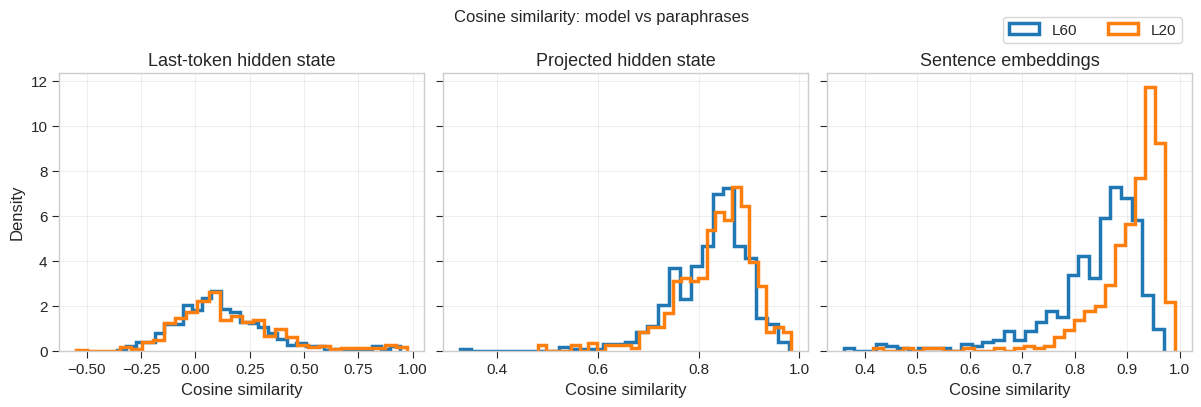

In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "lines.linewidth": 2.5,
})

# Prepare data
lths_l60 = hs_cos_l60.float().cpu().numpy()
lths_l20 = hs_cos_l20.float().cpu().numpy()
proj_l60 = proj_cos_l60.float().cpu().numpy()
proj_l20 = proj_cos_l20.float().cpu().numpy()
emb_l60 = emb_cos_l60.float().cpu().numpy()
emb_l20 = emb_cos_l20.float().cpu().numpy()

colors = {"l60": "#1f77b4", "l20": "#ff7f0e"}
bins = 30
hist_kwargs = dict(bins=bins, density=True, histtype="step", linewidth=2.5)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

axes[0].hist(lths_l60, color=colors["l60"], label="L60", **hist_kwargs)
axes[0].hist(lths_l20, color=colors["l20"], label="L20", **hist_kwargs)
axes[0].set_title("Last-token hidden state")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis="both", which="major", length=5)

axes[1].hist(proj_l60, color=colors["l60"], label="L60", **hist_kwargs)
axes[1].hist(proj_l20, color=colors["l20"], label="L20", **hist_kwargs)
axes[1].set_title("Projected hidden state")
axes[1].set_xlabel("Cosine similarity")
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="both", which="major", length=5)

axes[2].hist(emb_l60, color=colors["l60"], label="L60", **hist_kwargs)
axes[2].hist(emb_l20, color=colors["l20"], label="L20", **hist_kwargs)
axes[2].set_title("Sentence embeddings")
axes[2].set_xlabel("Cosine similarity")
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis="both", which="major", length=5)

fig.legend(["L60", "L20"], loc="upper right", ncol=2, frameon=True, bbox_to_anchor=(0.99, 0.99))
fig.suptitle("Cosine similarity: model vs paraphrases", y=0.99)
fig.tight_layout(pad=0.6)
fig.subplots_adjust(top=0.83)
plt.show()